In [403]:
import pandas as pd
messages = pd.read_csv('/kaggle/input/datasets/msp689/smsspam/SMSSpamCollection.txt',sep = "\t",names = ["labels","message"])

In [404]:
messages.shape

(5572, 2)

## Data Cleaning and Preprocessing


In [405]:
import re        #regularization
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [406]:
corpus = []
for i in range(0, len(messages)):
    review = re.sub('[^a-zA-Z]', ' ', messages['message'][i])
    review = review.lower()
    review = review.split()
    
    review = [lemmatizer.lemmatize(word) for word in review]
    review = ' '.join(review)
    corpus.append(review)

In [407]:
len(corpus)

5572

In [408]:
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

In [409]:
words = []
for sent in corpus:
    sent_token = sent_tokenize(sent)
    for sent in sent_token:
        words.append(simple_preprocess(sent))

In [410]:
words[0] ## first sentence

['go',
 'until',
 'jurong',
 'point',
 'crazy',
 'available',
 'only',
 'in',
 'bugis',
 'great',
 'world',
 'la',
 'buffet',
 'cine',
 'there',
 'got',
 'amore',
 'wat']

In [411]:
len(words)

5569

In [412]:
import gensim

## Train word2vec from scratch

In [413]:
model = gensim.models.Word2Vec(words,vector_size=100)

In [414]:
model.wv.index_to_key ## GET ALL THE VOCABULARY

['to',
 'you',
 'the',
 'and',
 'it',
 'in',
 'is',
 'me',
 'my',
 'for',
 'your',
 'call',
 'of',
 'that',
 'have',
 'on',
 'now',
 'are',
 'can',
 'so',
 'but',
 'not',
 'or',
 'we',
 'do',
 'get',
 'at',
 'ur',
 'if',
 'will',
 'be',
 'with',
 'no',
 'just',
 'this',
 'gt',
 'lt',
 'go',
 'how',
 'up',
 'when',
 'day',
 'ok',
 'what',
 'free',
 'from',
 'all',
 'out',
 'know',
 'll',
 'come',
 'like',
 'good',
 'time',
 'am',
 'then',
 'got',
 'wa',
 'there',
 'he',
 'love',
 'text',
 'only',
 'want',
 'send',
 'one',
 'need',
 'txt',
 'today',
 'by',
 'going',
 'don',
 'stop',
 'she',
 'home',
 'about',
 'lor',
 'sorry',
 'see',
 'still',
 'mobile',
 'take',
 'back',
 'da',
 'reply',
 'dont',
 'our',
 'think',
 'tell',
 'week',
 'phone',
 'hi',
 'new',
 'they',
 'later',
 'please',
 'any',
 'pls',
 'her',
 'ha',
 'did',
 'co',
 'msg',
 'been',
 'min',
 'an',
 'some',
 'dear',
 'night',
 'make',
 'who',
 'here',
 'message',
 'well',
 'say',
 'where',
 're',
 'thing',
 'much',
 'hope

In [415]:
model.corpus_count   # Size of vocabulary

5569

In [416]:
model.epochs

5

In [417]:
model.wv.similar_by_word('go')

[('him', 0.9989439845085144),
 ('tell', 0.9989431500434875),
 ('ask', 0.998887836933136),
 ('meet', 0.9988053441047668),
 ('then', 0.9987916350364685),
 ('already', 0.9987794160842896),
 ('wat', 0.9987764954566956),
 ('one', 0.998753011226654),
 ('thk', 0.9987073540687561),
 ('bit', 0.9986926317214966)]

In [418]:
model.wv['go'].shape

(100,)

### Avg Word2Vec

In [419]:
import numpy as np
def avg_word2vec(doc):
    vectors = [model.wv[word] for word in doc if word in model.wv.index_to_key]

    # If no words were found, return a zero vector of size 100
    if len(vectors) == 0:
        return np.zeros(100) 
    
    # Otherwise, return the mean of the vectors
    return np.mean(vectors, axis=0)


In [420]:
from tqdm import tqdm

In [421]:
X=[]
for i in tqdm(range(len(words))):
    X.append(avg_word2vec(words[i]))

100%|██████████| 5569/5569 [00:00<00:00, 10344.14it/s]


In [422]:
X[0]

array([-0.18983053,  0.26468068,  0.07443473,  0.10298755,  0.07504006,
       -0.50327075,  0.14635128,  0.49647933, -0.29080823, -0.10588018,
       -0.18192354, -0.42993242, -0.02497953,  0.07292083,  0.22730438,
       -0.16051719,  0.09739281, -0.28222367, -0.05774203, -0.58340836,
        0.19604726,  0.1923121 ,  0.07888257, -0.1868708 , -0.10705625,
        0.02290171, -0.3785272 , -0.24729769, -0.2695599 ,  0.02101626,
        0.28174582, -0.02326668,  0.08929255, -0.23248316, -0.11741544,
        0.41806924,  0.01341163, -0.15080601, -0.12646598, -0.37509385,
        0.14522718, -0.26166585, -0.18554473,  0.01464022,  0.26333597,
       -0.01464701, -0.2038037 , -0.05441306,  0.1103675 ,  0.13938828,
        0.15244593, -0.2142285 , -0.0396021 ,  0.08846173, -0.09925824,
        0.19411202,  0.16331516,  0.05912603, -0.2931394 ,  0.13678756,
        0.0078158 ,  0.13311368, -0.06083953, -0.14053153, -0.3208109 ,
        0.2577869 ,  0.07467445,  0.17830952, -0.356164  ,  0.32

In [423]:
len(X)

5569

In [424]:
##independent features
X_new = np.array(X)

In [425]:
X_new.shape

(5569, 100)

In [426]:
X_new[0].shape

(100,)

In [427]:
messages.shape

(5572, 2)

In [428]:
## Output
y = messages[list(map(lambda x: len(x)>0,corpus))] 
''' There was an error we have 5572 dp but when we done preprocessing
we got 5569 dp i.e 3 dp are being removed, so to resolve this isse we have done this.'''
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y['labels'])

In [429]:
y.shape

(5569,)

In [430]:
X=pd.DataFrame(X_new)

In [431]:
X.shape

(5569, 100)

In [432]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.189831,0.264681,0.074435,0.102988,0.075040,-0.503271,0.146351,0.496479,-0.290808,-0.105880,...,0.301169,0.130558,0.046634,0.134866,0.378498,0.317097,0.084816,-0.191417,0.153894,-0.107344
1,-0.165638,0.231233,0.060957,0.092385,0.062445,-0.445537,0.120228,0.436696,-0.245778,-0.077700,...,0.260648,0.110100,0.039782,0.114064,0.326606,0.266685,0.073380,-0.172119,0.127256,-0.093650
2,-0.186446,0.281879,0.096381,0.134575,0.073696,-0.560614,0.153633,0.505050,-0.304175,-0.115560,...,0.293134,0.138225,0.031455,0.144912,0.395744,0.300915,0.065855,-0.221787,0.190294,-0.110418
3,-0.259473,0.359170,0.092778,0.136509,0.099260,-0.665412,0.191716,0.672321,-0.394297,-0.132430,...,0.404166,0.167008,0.060884,0.180710,0.492761,0.426078,0.117785,-0.261376,0.193568,-0.134063
4,-0.228243,0.309400,0.087378,0.116449,0.096947,-0.575747,0.161159,0.584770,-0.339188,-0.121973,...,0.354957,0.140353,0.055481,0.155426,0.424201,0.370198,0.098330,-0.230828,0.170816,-0.125817


## Train Test Split

In [433]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [434]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

In [435]:
rf.fit(X_train,y_train)

RandomForestClassifier()

In [436]:
y_pred = rf.predict(X_test)

In [437]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score,classification_report

print(accuracy_score(y_test,y_pred))

0.9730700179533214


In [438]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       955
           1       0.94      0.87      0.90       159

    accuracy                           0.97      1114
   macro avg       0.96      0.93      0.94      1114
weighted avg       0.97      0.97      0.97      1114



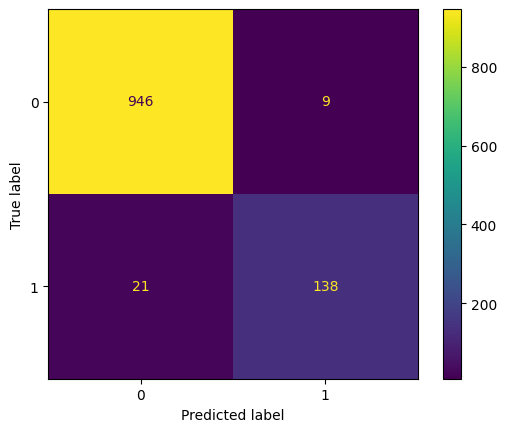

In [439]:
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred)).plot()